<a href="https://colab.research.google.com/github/javierrcastroo/DL_Proyecto/blob/main/NLP_Pr%C3%A1ctica_1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install emoji -q
!pip install langdetect -q
!pip install keybert -q
!pip install sentence-transformers -q
!pip install sentence-transformers umap-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 9.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 23.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 1.7 MB/s eta 0:00:00


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import emoji
import re
from collections import Counter
import matplotlib.pyplot as plt

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

from nltk.util import ngrams

from sklearn.ensemble import IsolationForest
from sklearn.metrics.pairwise import cosine_distances
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_distances

from langdetect import detect, DetectorFactory
from keybert import KeyBERT
import umap

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving admin.csv to admin.csv


En este colab vamos a realizar tanto el EDA cásico, como el ECA avanzado, ya que pensamos que ambos nos pueden dar información importante.

# EDA Clásico

Primero de todo, debemos importar los 3 csv que ha exportado doccano del corpus completo. Cada csv contiene los registros anotados de la persona encargada y los demás registros están sin anotar, por ello debemos juntarlos de la manera correcta para optener todos los registros correctamente anotados.

In [ ]:
import pandas as pd

df1 = pd.read_csv("admin.csv")
df2 = pd.read_csv("urko.csv")
df3 = pd.read_csv("juan.csv")


parte1 = df1.iloc[:42]        # registros 1-42 (42 registros)
parte2 = df2.iloc[42:79]      # registros 43–79 (39 registros)
parte3 = df3.iloc[79:]        # registros 80-118 (49 registros)

# Unirlos en uno solo
df = pd.concat([parte1, parte2, parte3], ignore_index=True)

## Exploración inicial

Vamos a empezar con la exploración inicial del dataset.

In [ ]:
df.shape

(118, 4)

In [ ]:
df.columns

Index(['id', 'text', 'label', 'Comments'], dtype='object')

In [ ]:
df.dtypes

,0
id,int64
text,object
label,object
Comments,float64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118 entries, 0 to 117
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        118 non-null    int64  
 1   text      118 non-null    object 
 2   label     118 non-null    object 
 3   Comments  0 non-null      float64
dtypes: float64(1), int64(1), object(2)
memory usage: 3.8+ KB


Como podemos ver, el dataset tiene 118 registros y 4 columnas que ha generado docanno al exportar los csv. Entre esas 4 columnas las relevantes son "text" que tiene la descripción y "label" que tiene la etiqueta.

A continuación vemos algunos registros como ejemplo:

In [ ]:
df.head()

,id,text,label,Comments
0,235,is a historical account written in the early 2...,American,NaN
1,236,is an English translation of the Bible publish...,British,NaN
2,237,is a memoir and travel book published in 1883....,American,NaN
3,238,is a historical account that was written in th...,British,NaN
4,239,is a historical account written in the late 19...,British,NaN


Ahora vamos a ver la cantidad de valores únicos que existen y la cantidad de nulos y duplicados.

In [ ]:
df.nunique()

,0
id,118
text,118
label,5
Comments,0


In [ ]:
df.isnull().sum()

,0
id,0
text,0
label,0
Comments,118


In [ ]:
df.duplicated().sum()

np.int64(0)

Como se puede intuir, no hay valores duplicados, todos los id y textos son únicos y todos los valores de lso comentarios son nulos, ya que en docanno no hemos puesto comentarios.

Mostramos de manera visual la distribución de las etiquetas.

,count
label,
Ancient,31
American,29
British,24
MidAge,18
European,16


<Axes: xlabel='count', ylabel='label'>

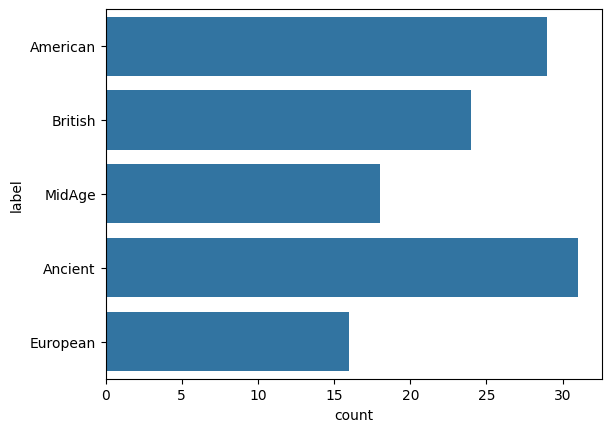

In [ ]:
display(df["label"].value_counts())

sns.countplot(df['label'])

Vamos a comprobar la presencia o ausencia de los siguientes elementos en el corpus.

In [ ]:
# emojis por review
df['emoji_count'] = df['text'].apply(lambda x: emoji.emoji_count(str(x)))

# mayúsculas por review
df['caps_ratio'] = df['text'].apply(lambda x: sum(1 for c in str(x) if c.isupper()) / len(str(x)) if len(str(x)) > 0 else 0)

# url por review
df['has_url'] = df['text'].apply(lambda x: int(bool(re.search(r'http[s]?://\S+', str(x)))))

# mentions por review
df['has_mention'] = df['text'].apply(lambda x: int(bool(re.search(r'@\S+', str(x)))))

# puntuaciones por review
df['punct_density'] = df['text'].apply(lambda x: len(re.findall(r'[!?.¡¿,;:]', str(x))) / len(str(x)) if len(str(x)) > 0 else 0)

display(df.head())


,id,text,label,Comments,emoji_count,caps_ratio,has_url,has_mention,punct_density
0,235,is a historical account written in the early 2...,American,NaN,0,0.034816,0,0,0.021277
1,236,is an English translation of the Bible publish...,British,NaN,0,0.052823,0,0,0.018215
2,237,is a memoir and travel book published in 1883....,American,NaN,0,0.019920,0,0,0.023904
3,238,is a historical account that was written in th...,British,NaN,0,0.022556,0,0,0.022556
4,239,is a historical account written in the late 19...,British,NaN,0,0.018557,0,0,0.015464


En todo el corpus

In [ ]:
global_stats = df[['emoji_count', 'caps_ratio', 'has_url', 'has_mention', 'punct_density']].mean()
print("Promedio global de estilo del corpus:\n", global_stats)

Promedio global de estilo del corpus:
 emoji_count      0.000000
caps_ratio       0.019279
has_url          0.000000
has_mention      0.000000
punct_density    0.019415
dtype: float64


Si nos fijamos en las métricas, comprobamos que no existen emojis, urls o menciones en el copus. Además, la proporción de mayusculas y signos de puntuación esta en aprox 2% del corpus cada una de ellas.

## Longitud o número de palabras

Número de palabras únicas.

In [ ]:
all_words = [word for text in df['text'] for word in str(text).split()]

unique_words = set(all_words)

print("Número de palabras únicas en el corpus:", len(unique_words))


Número de palabras únicas en el corpus: 3974


Número de palabras por review.

<Axes: title={'center': 'Distribución de la longitud de las descripciones'}, xlabel='Número de palabras por descripción', ylabel='Frecuencia'>

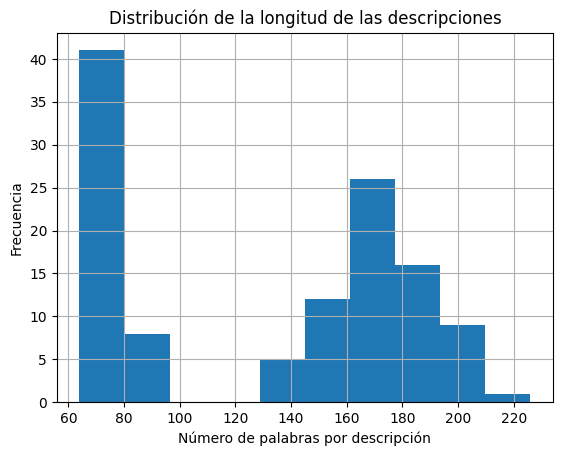

In [ ]:
def word_count(text):
    tokens = re.findall(r'\w+', str(text))
    return len(tokens)

df['word_count']=df['text'].apply(word_count)

plt.xlabel('Número de palabras por descripción')
plt.ylabel('Frecuencia')
plt.title('Distribución de la longitud de las descripciones')

df['word_count'].hist()

,word_count
label,
American,115.793103
Ancient,111.612903
British,155.916667
European,145.812500
MidAge,152.833333


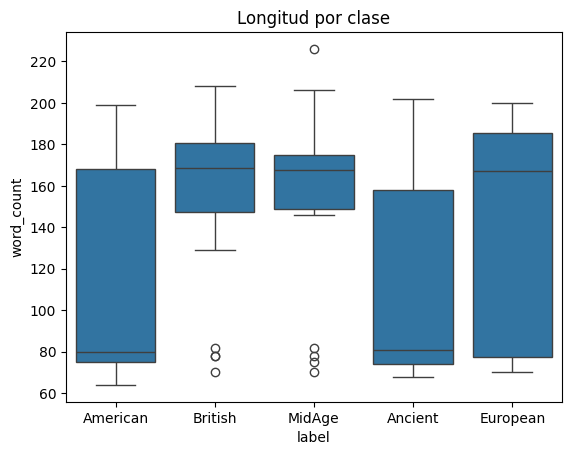

In [ ]:
display(df.groupby('label')['word_count'].mean())


sns.boxplot(data=df, x="label", y="word_count")
plt.title("Longitud por clase")
plt.show()

In [ ]:
df.groupby('label')["word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
American,29.0,115.793103,51.469394,64.0,75.00,80.0,168.00,199.0
Ancient,31.0,111.612903,46.528613,68.0,74.00,81.0,158.00,202.0
British,24.0,155.916667,40.321444,70.0,147.25,168.5,180.50,208.0
European,16.0,145.812500,51.197941,70.0,77.25,167.0,185.50,200.0
MidAge,18.0,152.833333,45.881241,70.0,148.75,167.5,174.75,226.0


En esta sección vemos que la longitud de las descripciones se pueden agrupar en dos categorian: la primera con descripciones cortas (70 palabras aprox) y la segunda con descripciones largas (170 palabras aprox).

Además, tambien hemos visto que los textos clasificados como historia Americana o Europea son relativamente más cortos que los demás.

## Palabras únicas

Vamos a realizar las mismas actividades pero sin contar palabras repetidas. La pregunta que queremos responder es, ¿será el vocabulario más rico en el caso de ser un label u otro?

<Axes: >

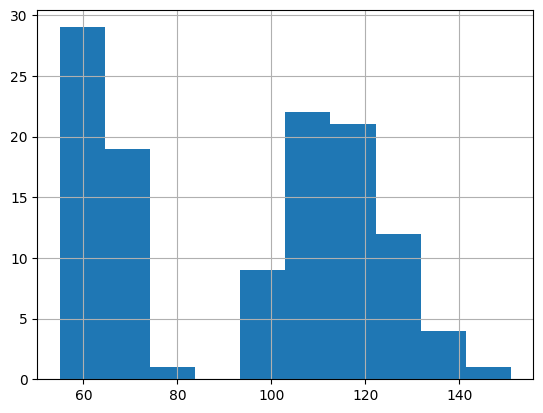

In [ ]:
df['unique_word_count'] =df['text'].apply(lambda x: len(set(str(x).split())))

df['unique_word_count'].hist()

Número promedio de palabras únicas por label:

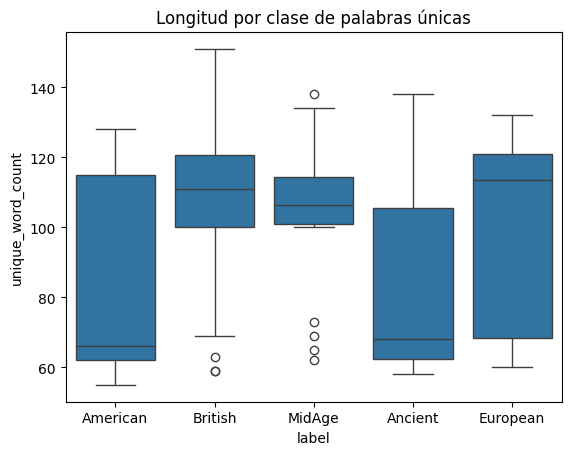

In [ ]:
df.groupby('label')['unique_word_count'].mean()

sns.boxplot(data=df, x="label", y="unique_word_count")
plt.title("Longitud por clase de palabras únicas")
plt.show()

In [ ]:
df.groupby('label')["unique_word_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
American,29.0,84.551724,27.788212,55.0,62.0,66.0,115.00,128.0
Ancient,31.0,82.645161,24.665155,58.0,62.5,68.0,105.50,138.0
British,24.0,106.291667,23.452967,59.0,100.0,111.0,120.75,151.0
European,16.0,102.312500,27.214503,60.0,68.5,113.5,121.00,132.0
MidAge,18.0,103.000000,22.008020,62.0,101.0,106.5,114.50,138.0


Vemos que a pesar de reducirse levemente las longitudes, se siguen manteniendo ñas mismas tendencias que usando todas las palabras.

Una medida habitual para cuantificar la diversidad léxica estructural de un texto es su type-token ratio o ttr, que se mide entre 0 y 1.

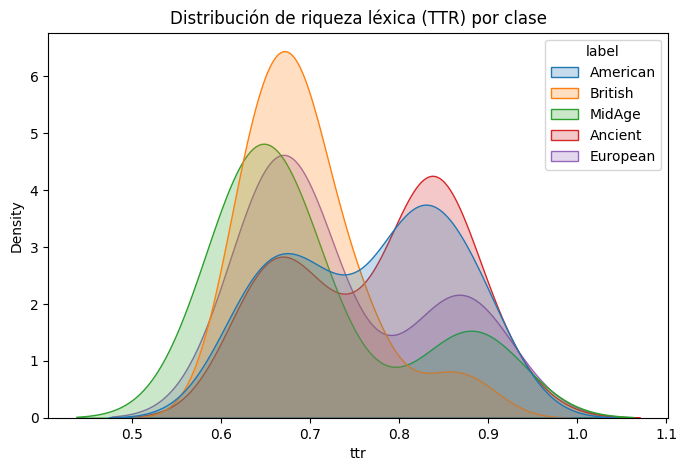

In [ ]:
df['ttr'] = df['unique_word_count'] / df['word_count']

plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x="ttr", hue="label", fill=True, common_norm=False)
plt.title("Distribución de riqueza léxica (TTR) por clase")
plt.show()


## Distribución de palabras

### Palabras más frecuentes

¿Cuál será el ranking de palabras más utilizadas?

In [ ]:
rankings = {}

for label in df["label"].unique():
    texts = df[df["label"] == label]["text"]
    words = [word for text in texts for word in text.lower().split() if word]
    word_counts = Counter(words)
    rankings[label] = word_counts.most_common(10)

rankings

{'American': [('the', 292),
  ('of', 132),
  ('and', 129),
  ('a', 80),
  ('in', 73),
  ('to', 59),
  ('his', 49),
  ('is', 32),
  ('as', 32),
  ('for', 31)],
 'British': [('the', 332),
  ('of', 181),
  ('and', 161),
  ('a', 96),
  ('in', 87),
  ('her', 58),
  ('to', 53),
  ('as', 40),
  ('for', 33),
  ('on', 33)],
 'MidAge': [('the', 312),
  ('of', 158),
  ('and', 122),
  ('a', 61),
  ('to', 46),
  ('in', 44),
  ('historical', 34),
  ('as', 33),
  ('for', 25),
  ('that', 25)],
 'Ancient': [('the', 291),
  ('of', 158),
  ('and', 146),
  ('a', 77),
  ('in', 59),
  ('to', 56),
  ('from', 37),
  ('is', 36),
  ('this', 32),
  ('...', 31)],
 'European': [('the', 223),
  ('of', 113),
  ('and', 90),
  ('a', 50),
  ('to', 35),
  ('in', 35),
  ('his', 33),
  ('with', 24),
  ('that', 24),
  ('this', 22)]}

¿Y por label?

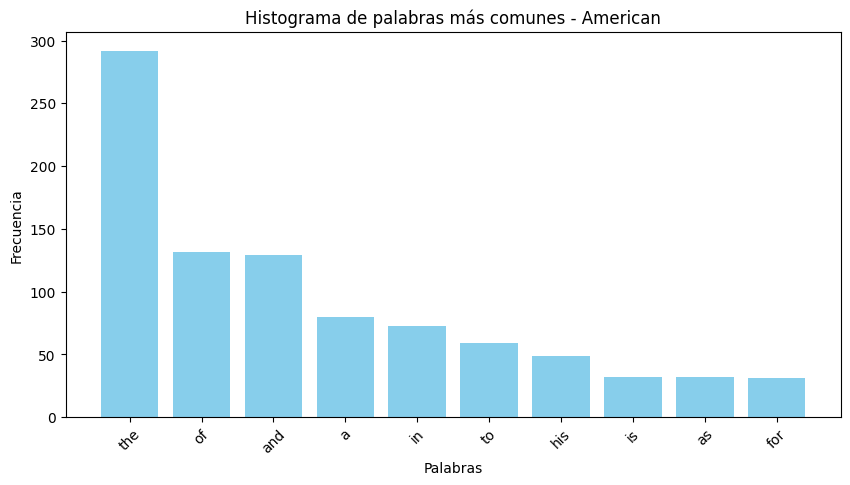

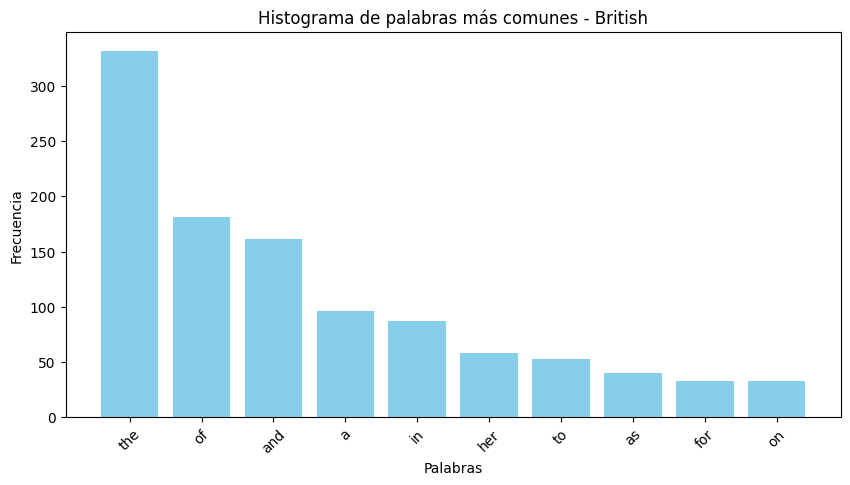

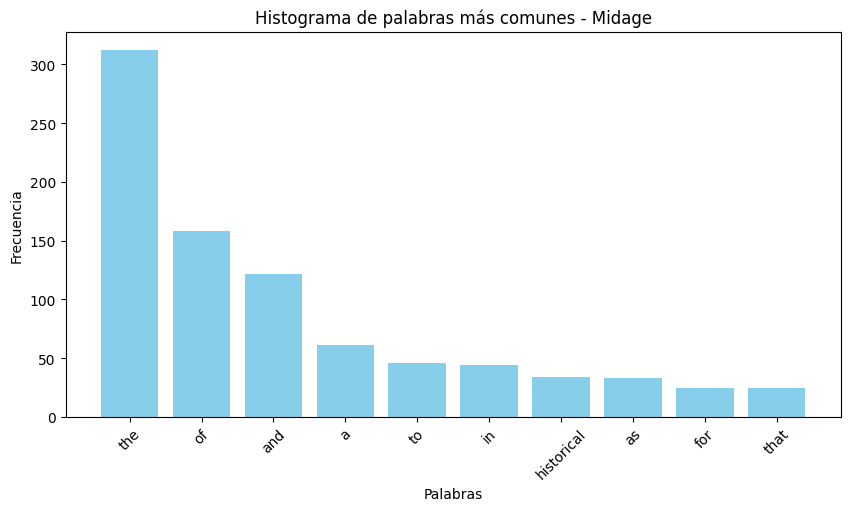

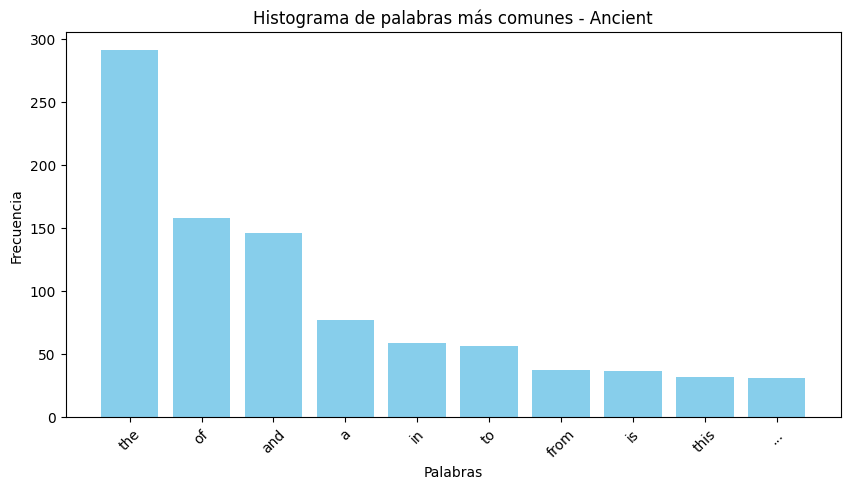

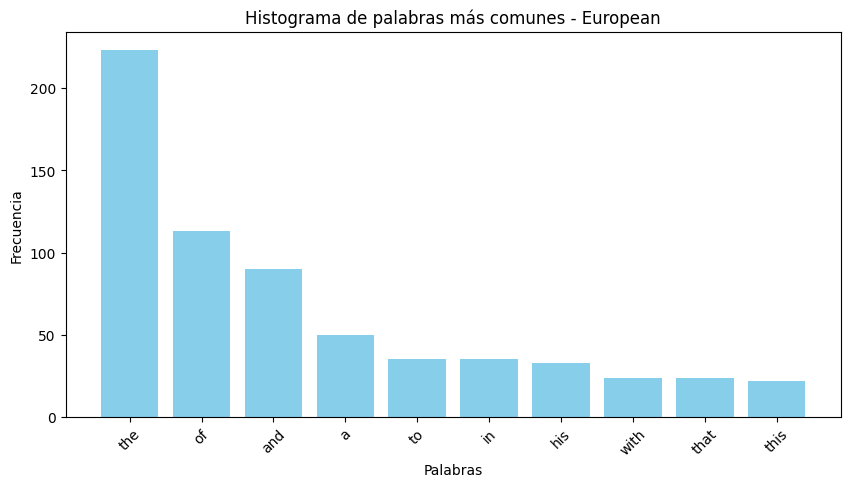

In [ ]:
def plot_histogram(word_counts, history):
    words, counts = zip(*word_counts)
    plt.figure(figsize=(10, 5))
    plt.bar(words, counts, color='skyblue')
    plt.xlabel("Palabras")
    plt.ylabel("Frecuencia")
    plt.title(f"Histograma de palabras más comunes - {history.capitalize()}")
    plt.xticks(rotation=45)
    plt.show()

for history, word_counts in rankings.items():
    plot_histogram(word_counts, history)

Vemos que las palabras más frecuentes son stop words como 'the', 'of' o similares.

#### Stop words

Vamos a eliminar los stop words, ya que suelen ser artículos, preposiciones, pronombres y otras palabras funcionales que no aportan información relevante en un análisis de texto.

In [ ]:
stopwords_english = stopwords.words('english')

stopwords_english

['a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 'her',
 'here',
 'hers',
 'herself',
 "he's",
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 'if',
 "i'll",
 "i'm",
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 "i've",
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
df['Cleaned_text'] = df['text'].apply(lambda x: ' '.join([word for word in str(x).lower().split() if word not in stopwords_english]))

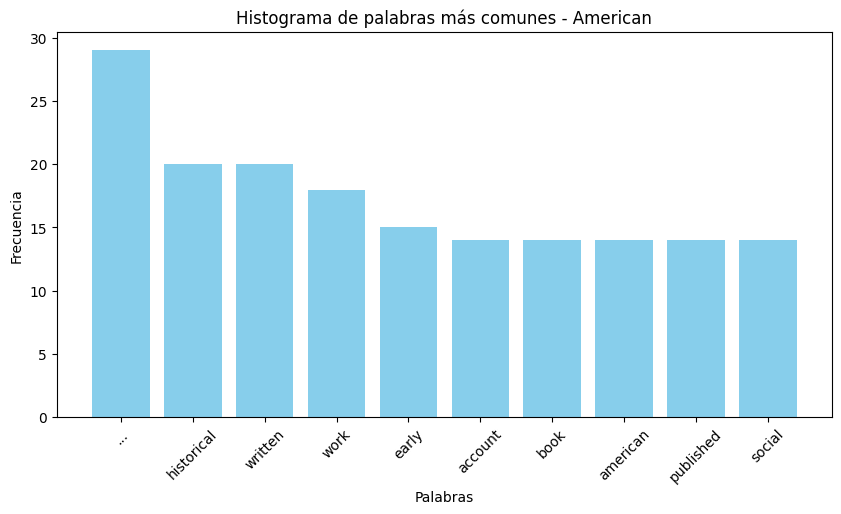

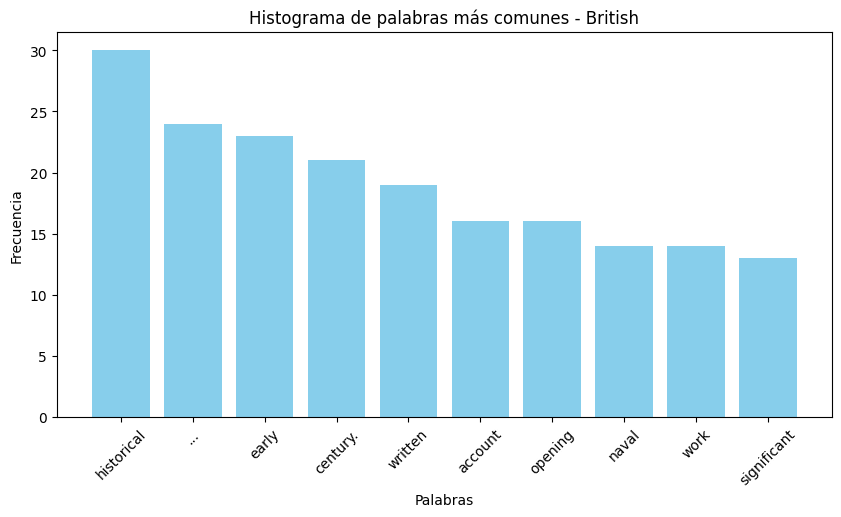

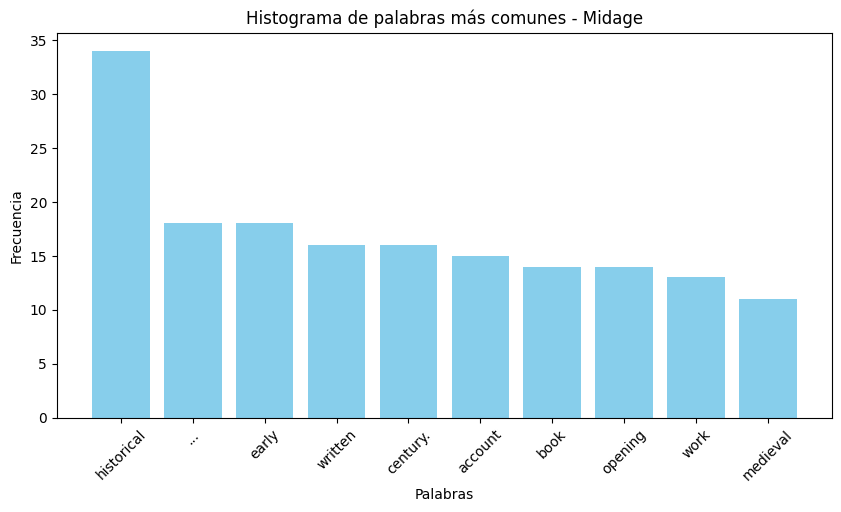

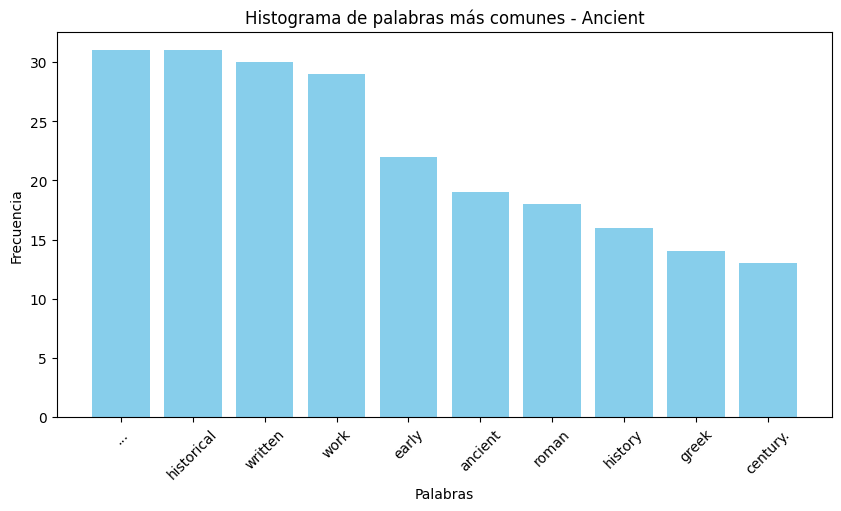

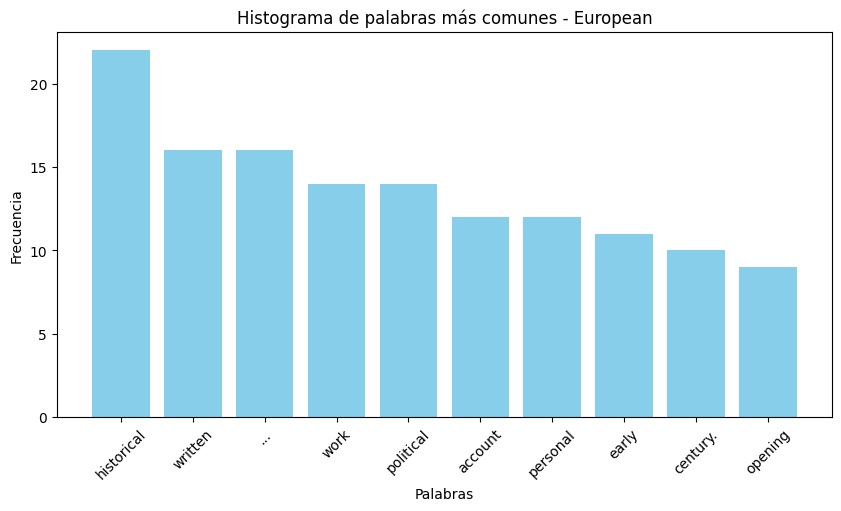

In [ ]:
rankings = {}

for label in df["label"].unique():
    texts = df[df["label"] == label]["Cleaned_text"]
    words = [word for text in texts for word in text.lower().split() if word]
    word_counts = Counter(words)
    rankings[label] = word_counts.most_common(10)

for history, word_counts in rankings.items():
    plot_histogram(word_counts, history)

Vemos que ya no aparecen stop words, sin embargo, siguen compartiendo palabras más comunes entre las distintas etiquetas, como 'historical' o 'early'.

### Palabras menos frecuentes

En muchas ocasiones, para crear una representación y ahorrar recursos se omiten palabras por debajo de un umbral. En este caso, por ejemplo, vamos a considerar palabras poco frecuentes a aquellas que aparezcan una sola vez en el dataset.

Por label:

In [ ]:
oov_per_label = {}

for label in df['label'].unique():
    texts = df[df['label'] == label]['text']

    words = [word for text in texts for word in str(text).lower().split()]
    freq_dist = Counter(words)

    oov_words = [word for word, freq in freq_dist.items() if freq == 1]

    oov_per_label[label] = oov_words

    print(f"\label: {label}")
    print("Número de oov:", len(oov_words))
    print("Algunas palabras oov:", oov_words[:20])


\label: American
Número de oov: 992
Algunas palabras oov: ['42nd', 'infantry', 'officers', 'served', 'it.', 'composition', 'leadership', 'unit', 'i.', 'lieutenant', 'harold', 'stanley', "johnson's", 'foreword,', 'formation', 'roster.', 'connections', 'effective', 'teamwork,', 'noting']
\label: British
Número de oov: 957
Algunas palabras oov: ['bible', '1582', '1610.', 'created', 'catholic', 'scholars', 'exile', 'reformation,', 'rendered', 'latin', 'vulgate', 'counter-reformation', 'effort.', 'appeared', 'rheims', '1582,', 'old', 'followed', 'douai', 'nearly']
\label: MidAge
Número de oov: 692
Algunas palabras oov: ['tracing', 'antiquity', 'ages.', 'focuses', 'methods,', 'materials,', 'employed', 'creation,', 'illumination', 'form.', 'comprehensive', 'overview', 'writing', 'decoration', 'sixteenth', 'marking', 'texts', 'printed', 'works.', 'middleton']
\label: Ancient
Número de oov: 912
Algunas palabras oov: ['similar', 'destiny—alexander', 'demosthenes', 'cicero—to', 'plutarch', 'ethic

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_148/1214401380.py:13: SyntaxWarning: invalid escape sequence '\l'
  print(f"\label: {label}")


Ratio:

In [ ]:
oov = sum(1 for word, freq in freq_dist.items() if freq == 1)
print("% de palabras únicas en todo el vocabulario ratio:", oov / len(freq_dist))

% de palabras únicas en todo el vocabulario ratio: 0.7164835164835165


Listado:

In [ ]:
oov_words = [word for word, freq in freq_dist.items() if freq == 1]
print("Palabras que aparecen solo una vez:", oov_words[:20])

Palabras que aparecen solo una vez: ['13th-century', 'travelogue', '1298-1299.', 'legendary', "polo's", 'asia', '1271', '1295', 'remarkable', 'kublai', 'khan.', 'dictated', 'venetian', 'explorer', 'romance', 'writer', 'rustichello', 'imprisoned', 'genoa,', 'adventure']


### Distribución del vocabulario total (Ley de Zipf)

Vamos a comprobar si la frecuencia de aparición de las palabras sigue una distribución tipo Zipf, algo habitual en los corpus de PLN, donde unas pocas palabras son muy frecuentes y la mayoría aparecen raramente.

[('historical', 137),
 ('...', 118),
 ('written', 101),
 ('early', 89),
 ('work', 88),
 ('century.', 71),
 ('account', 69),
 ('opening', 63),
 ('book', 46),
 ('political', 45),
 ('narrative', 42),
 ('introduces', 41),
 ('personal', 41),
 ('various', 37),
 ('significant', 36),
 ('social', 35),
 ('life', 35),
 ('sets', 34),
 ('history', 33),
 ('stage', 33),
 ('late', 32),
 ('figures', 31),
 ('including', 31),
 ('19th', 31),
 ('20th', 28),
 ('exploration', 28),
 ('text', 27),
 ('cultural', 26),
 ('detailed', 26),
 ('events', 26)]

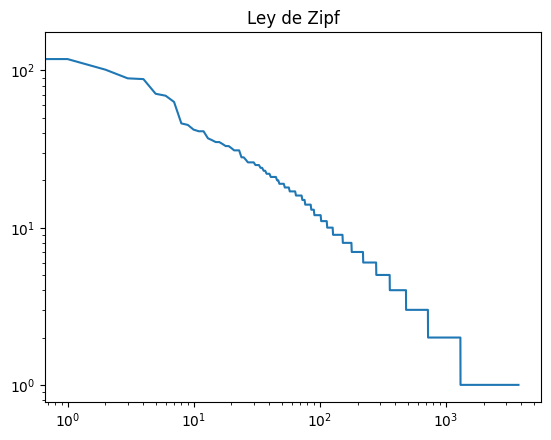

In [ ]:
all_words = [word for text in df['Cleaned_text']
             for word in text.lower().split()]

freq_dist = Counter(all_words)
common_words = freq_dist.most_common(30)
display(common_words)

freqs = list(freq_dist.values())
plt.plot(sorted(freqs, reverse=True))
plt.yscale('log')
plt.xscale('log')
plt.title("Ley de Zipf")
plt.show()

Viendo el gráfico, podemos confirmar que sí se sigue ña ñey de Zipf.

### N-gramas

Aunque en el enfoque clásico su utilidad es mucho más limitada, la secuencias de palabras son un factor muy importante en diversas actividadas de PLN.

In [ ]:
bigrams = []

for text in df['text']:
    tokens = text.lower().split()
    bigrams.extend(list(ngrams(tokens, 2)))

Counter(bigrams).most_common(20)

[(('of', 'the'), 201),
 (('in', 'the'), 119),
 (('and', 'the'), 111),
 (('is', 'a'), 109),
 (('written', 'in'), 80),
 (('a', 'historical'), 66),
 (('historical', 'account'), 57),
 (('the', 'opening'), 55),
 (('to', 'the'), 54),
 (('account', 'written'), 51),
 (('as', 'a'), 51),
 (('opening', 'of'), 46),
 (('the', 'early'), 43),
 (('on', 'the'), 42),
 (('the', 'book'), 41),
 (('into', 'the'), 38),
 (('during', 'the'), 35),
 (('century.', 'this'), 35),
 (('the', 'stage'), 33),
 (('the', 'late'), 32)]

Vemos que los bigramas más comunes son articulo + nombre. Si probamos con el texto sin stop words, veremos que pierden bastante el sentido de los bigramas.

In [ ]:
bigrams = []

for text in df['Cleaned_text']:
    tokens = text.lower().split()
    bigrams.extend(list(ngrams(tokens, 2)))

Counter(bigrams).most_common(20)

[(('historical', 'account'), 57),
 (('account', 'written'), 52),
 (('written', 'early'), 34),
 (('19th', 'century.'), 30),
 (('early', '20th'), 28),
 (('20th', 'century.'), 28),
 (('century.', 'work'), 28),
 (('written', 'late'), 26),
 (('late', '19th'), 25),
 (('sets', 'stage'), 23),
 (('century.', 'book'), 14),
 (('opening', 'book'), 14),
 (('work', 'written'), 9),
 (('work', 'explores'), 8),
 (('setting', 'stage'), 8),
 (('book', 'introduces'), 8),
 (('detailed', 'exploration'), 7),
 (('stage', 'detailed'), 7),
 (('century.', 'volume'), 7),
 (('events', 'shaped'), 7)]

## Correlaciones

Vamos a comprobar si alguna de estas careacterísticas tiene influencia en el label.

In [ ]:
df['Label_number'] = df['label'].map({'British': 4, 'American': 3, 'Ancient': 2, 'MidAge': 1, 'European': 0})

<Axes: >

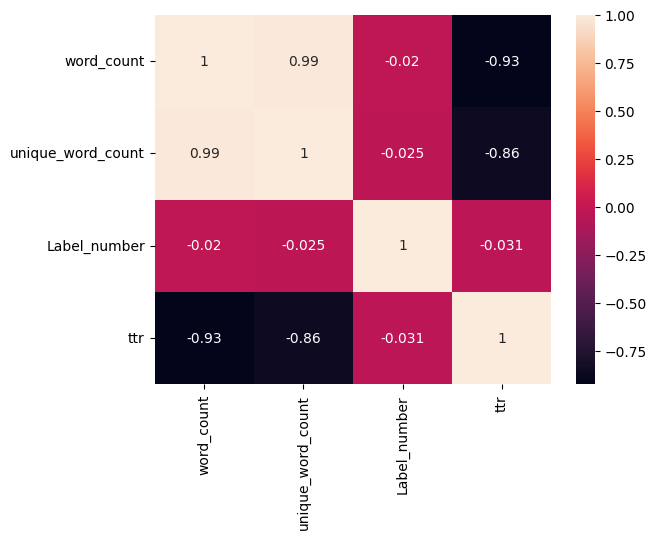

In [ ]:
corr=df[['word_count', 'unique_word_count', 'Label_number', 'ttr']].corr()
sns.heatmap(corr,annot=True)

Vemos que las características de word_count, unique_word_count y ttr son prácticamente independientes a label_number (sus correlaciones son practicamente 0).

Por otro lado, logicamnete word_count y unique_word_count estan fuertemente relacionadas (0,99).

Además, como ttr es una división entre unique_word_count y word_count tienen una fuerte correlación negativa, especialmente con word_count (el dividor) acercandose al -1.

# EDA Avanzado

## Exploración inicial

Es equivalente a la "Exploración inicial" del EDA clásico, por ello, no se va a repetir.

## Perfilado estadístico clásico

Es equivalente a la "Longitud o número de palabras" del EDA clásico, por ello, no se va a repetir.

## Detectar de outliers

En ML clásico el outlier es una anomalía estadística en un espacio numérico. En PLN es algo más complejo, y tiende a ser estructural, léxico, semántico o incluso un error de anotación.

Por tanto, un outlier no es simplemente un punto lejano en un espacio vectorial, sino que puede manifestarse en distintos niveles:

- Estructural (longitud): textos excesivamente largos o cortos respecto al resto del corpus.

- Léxico (vocabulario): uso de tokens extremadamente raros, ruido, caracteres corruptos o cadenas sin significado.

- Semántico (significado): textos cuyo contenido temático no pertenece al dominio principal del corpus.

### Outliers por longitud

In [ ]:
def detect_structural_outliers(df):
    df = df.copy()

    features = [
        "word_count",
        "emoji_count",
        "caps_ratio",
        "punct_density",
        "ttr"
    ]

    for col in features:
        if col not in df.columns:
            raise ValueError(f"La columna '{col}' no existe en el DataFrame.")

        numeric_col = df[col].astype(float)

        # Calcular IQR
        Q1 = numeric_col.quantile(0.25)
        Q3 = numeric_col.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR


        df[f"{col}_outlier"] = (numeric_col < lower) | (numeric_col > upper)


    outlier_cols = [f"{f}_outlier" for f in features]
    df["structural_outlier"] = df[outlier_cols].any(axis=1)

    summary = {f"{f}_outliers": df[f"{f}_outlier"].sum() for f in features}
    summary["structural_outliers"] = df["structural_outlier"].sum()

    return df, summary

df, report = detect_structural_outliers(df)

In [ ]:
report

{'word_count_outliers': np.int64(0),
 'emoji_count_outliers': np.int64(0),
 'caps_ratio_outliers': np.int64(5),
 'punct_density_outliers': np.int64(9),
 'ttr_outliers': np.int64(0),
 'structural_outliers': np.int64(13)}

Se han detectado 5 outliers por  mayúsculas, 9 por puntuaciones y 13 por estructura.

### Outliers léxicos

In [ ]:
def tokenize(text):
    return re.findall(r"\b\w+\b", str(text).lower())

def count_rare_tokens_in_text(text, rare_tokens):
    tokens = tokenize(text)
    return sum(token in rare_tokens for token in tokens)

def detect_lexical_outliers(df, text_col="text", percentile=0.99):

    df = df.copy()

    all_tokens = []
    for text in df[text_col]:
        all_tokens.extend(tokenize(text))

    token_counts = Counter(all_tokens)

    # Tokens cuya frecuencia es 1
    rare_tokens = {token for token, count in token_counts.items() if count == 1}

    # Contar rarezas por documento
    df["rare_token_count"] = df[text_col].apply(lambda x: count_rare_tokens_in_text(x, rare_tokens))

    #  Marcar outliers según percentil o poner 0 ver todos los ejemplso que contiene una palabra rara
    threshold = df["rare_token_count"].quantile(percentile)
    df["lexical_outlier"] = df["rare_token_count"] > threshold

    summary = {
        "total_rows": len(df),
        "lexical_outliers": df["lexical_outlier"].sum(),
    }

    return df, summary

df, report = detect_lexical_outliers(df)

In [ ]:
report

{'total_rows': 118, 'lexical_outliers': np.int64(1)}

Se ha detectado 1 outlier por léxico.

### Outliers semánticos

Aprovecharemos la sofisticación de los embeddings de LLMs:

In [ ]:
def detect_semantic_outliers_absolute(df, text_col="text", distance_threshold=0.3):

    model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

    embeddings = model.encode(df[text_col].tolist(), show_progress_bar=True)

    centroid = embeddings.mean(axis=0, keepdims=True)

    distances = cosine_distances(embeddings, centroid).flatten()
    df['semantic_distance'] = distances

    df['domain_outlier'] = distances > distance_threshold

    summary = {
        "total_rows": len(df),
        "domain_outliers": df['domain_outlier'].sum(),
        "distance_threshold": distance_threshold
    }

    return df, summary
df, report = detect_semantic_outliers_absolute(df, text_col="text", distance_threshold=0.5) # Usando 0.5 como umbral, pero se puede usar otro.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
report

{'total_rows': 118, 'domain_outliers': np.int64(6), 'distance_threshold': 0.5}

Se han detectado 6 outliers semánticos. En el gráfico de abajo podemos ver la distribución de las distancias semánticas.

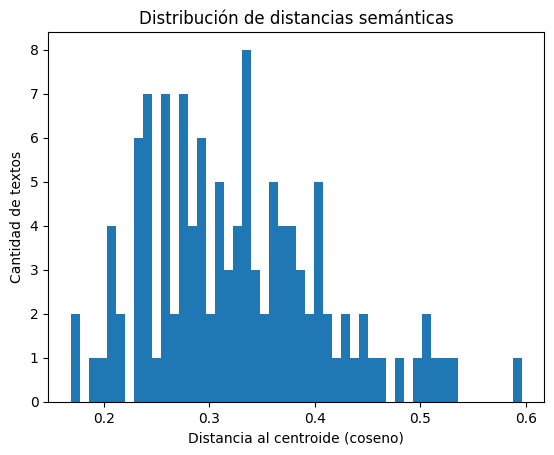

In [ ]:
plt.hist(df['semantic_distance'], bins=50)
plt.xlabel("Distancia al centroide (coseno)")
plt.ylabel("Cantidad de textos")
plt.title("Distribución de distancias semánticas")
plt.show()

## Detectar idioma

Detectar el idioma de cada texto permite asegurarnos de que el corpus es homogéneo y evitar que datos en otros idiomas afecten el análisis. Este paso en nuestro caso no es obligatorio, ya que al anotar los textos nos hemos asegurado que son en ingés. Aun así, vamos a hacerlo.

In [ ]:
DetectorFactory.seed = 42

def detectar_idioma(texto):
    try:
        return detect(str(texto))
    except:
        return "error"

df['idioma'] = df['text'].apply(detectar_idioma)

print(df['idioma'].value_counts())

idioma
en    118
Name: count, dtype: int64


## Temas representativos: por medio de palabras clave basadas en embeddings

En el EDA clásico miramos frecuencias, histogramas, n-gramas, pero por ejemplo, con KeyBERT podemos ir un paso más allá: resumir semánticamente el corpus y entender qué conceptos captarán los embeddings de un LLM.

KeyBert utiliza un modelo de embeedings multilingüe, solo le pasamos la lista de stopwords en inglés.

En este caso, se concatenan todas las descripciones de una misma clase en un único texto. A continuación, KeyBERT calcula qué palabras o frases representan mejor ese conjunto de descripciones mediante la comparación entre los embeddings de los candidatos y la representación vectorial del texto completo de cada etiqueta


In [ ]:
kw_model = KeyBERT()

labels = df['label'].unique()

for label in labels:
    text_label = " ".join(df[df['label']==label]['text'])
    keywords_label = kw_model.extract_keywords(
        text_label,
        keyphrase_ngram_range=(1,2), # se puede cambiar
        stop_words=stopwords_english,
        top_n=20
    )
    print(f"\nPalabras clave para la etiqueta '{label}':")
    print(keywords_label)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Palabras clave para la etiqueta 'American':
[('infantry division', 0.5335), ('42nd infantry', 0.5249), ('rainbow division', 0.4962), ('unit military', 0.4871), ('chronicled military', 0.487), ('war novel', 0.458), ('infantry', 0.4575), ('regiment', 0.4425), ('soldiers served', 0.4384), ('officers soldiers', 0.4319), ('war general', 0.4188), ('among soldiers', 0.4063), ('american forces', 0.393), ('union army', 0.3873), ('army', 0.3865), ('military world', 0.3854), ('honor serving', 0.3816), ('members expedition', 0.3798), ('military campaigns', 0.3763), ('history book', 0.3758)]

Palabras clave para la etiqueta 'British':
[('memoir beresford', 0.4716), ('naval history', 0.4273), ('historical naval', 0.4155), ('maritime history', 0.4133), ('new testament', 0.4072), ('fleet 1858', 0.4009), ('exploration beresford', 0.3981), ('bible published', 0.3941), ('beresford recounts', 0.3839), ('old testament', 0.3831), ('beresford life', 0.379), ('beresford', 0.3767), ('navy 1859', 0.3708), ('br

Vemos que las palabras más destacadas:
- El historia de America son terminos relacionados con la gerra.
- En historia de Rino Unido se destacan la marina.
- En historia de la Edad Media los manuscritos.
- En historia de la Antiguedad son el imperio romano.
- En historia de Europa no se aprecia un tema claro.

 ## Proyección semántica: a través de embeddings / clusters

Cada descripción se convierte en un vector numérico que captura significado y contexto. Las palabras con significados similares tendrán vectores cercanos.

Para su visualización, es necesario reducir la dimensionalidad, en este caso emplearemos umap.

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


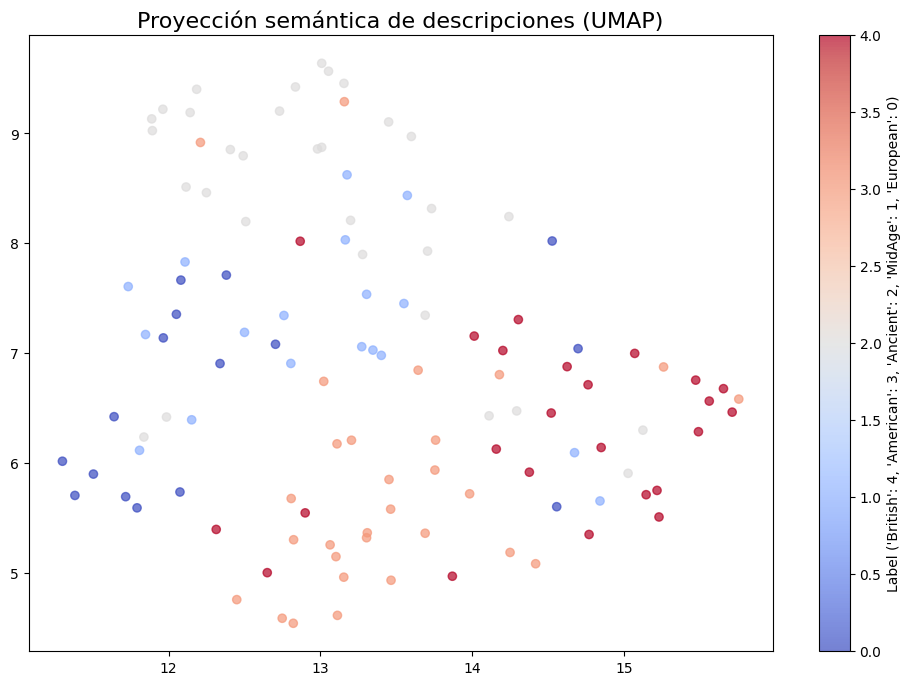

In [ ]:
# Usamos un modelo multilingüe de SentenceTransformers
model = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')

# Obtener embeddings del corpus
embeddings = model.encode(df['text'].tolist(), show_progress_bar=True)

# Reducir dimensionalidad con UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
reduced = reducer.fit_transform(embeddings)

plt.figure(figsize=(12,8))
scatter = plt.scatter(
    reduced[:,0], reduced[:,1],
    c=df['Label_number'],
    cmap='coolwarm',
    alpha=0.7
)
plt.title("Proyección semántica de descripciones (UMAP)", fontsize=16)
plt.colorbar(scatter, label="Label ('British': 4, 'American': 3, 'Ancient': 2, 'MidAge': 1, 'European': 0)")
plt.show()

Vemos que no hay una separación clara de los clusters, pero sí se ve un ligero orden interno, por ejemplo, los registros de la historia Antigua se encuentran en gran media arriba a la izquierda.

Con esto ya hemos termidado el EDA y hemos conseguido varias conclusiones que hemos comentado a lo largo del Colab.